In [ ]:
# Install necessary libraries
!pip install kagglehub pandas matplotlib seaborn opencv-python pillow
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import kagglehub
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
# 1. Download the Dataset
print("Downloading ASL dataset...")
path = kagglehub.dataset_download("grassknoted/asl-alphabet")
print("Path to dataset files:", path)

# Define the training directory path based on the dataset structure
train_dir = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')
print("Training directory:", train_dir)

Path to dataset files: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1
Training directory: /root/.cache/kagglehub/datasets/grassknoted/asl-alphabet/versions/1/asl_alphabet_train/asl_alphabet_train


In [ ]:
# 2. Reading Dataset and Classes
print("Scanning directories for images...")
image_paths = glob.glob(os.path.join(train_dir, '**', '*.jpg'), recursive=True)

data = []
for img_path in image_paths:
    # The class name is the folder name containing the image
    class_name = os.path.basename(os.path.dirname(img_path))
    data.append({"image_path": img_path, "class_name": class_name})

df = pd.DataFrame(data)

print(f"Total number of images found: {len(df)}")
print(f"Number of classes: {df['class_name'].nunique()}")
print(f"Class Names: {sorted(df['class_name'].unique())}")

Scanning directories for images...
Total number of images found: 87000
Number of classes: 29
Class Names: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']



Number of images per class:
class_name
L          3000
T          3000
W          3000
C          3000
O          3000
N          3000
J          3000
H          3000
R          3000
X          3000
S          3000
Q          3000
nothing    3000
D          3000
del        3000
P          3000
M          3000
G          3000
B          3000
space      3000
U          3000
E          3000
V          3000
Z          3000
F          3000
I          3000
A          3000
K          3000
Y          3000
Name: count, dtype: int64


/tmp/ipykernel_3651/4253963064.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='mako')


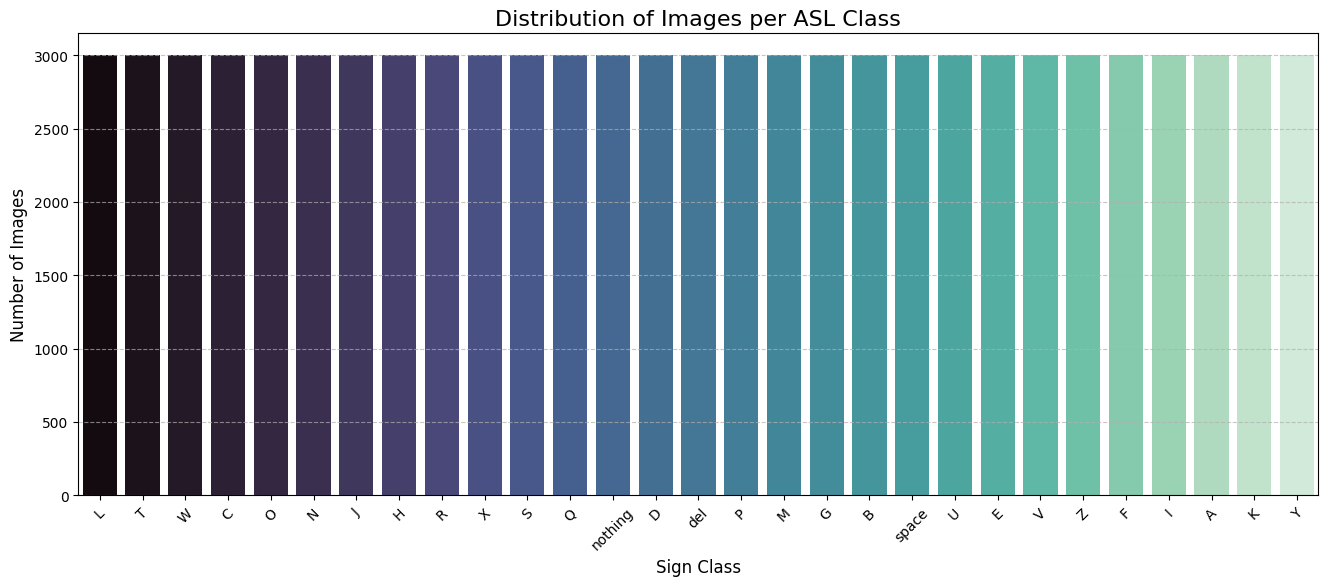


--- Imbalance Analysis ---
The dataset is perfectly balanced. All classes have around 3000 images.
Person 2 does not need to apply class-balancing techniques.


In [ ]:
# 3. Class Distribution & Imbalance Check
class_counts = df['class_name'].value_counts()
print("\nNumber of images per class:")
print(class_counts)

# Visualization of Class Distribution
plt.figure(figsize=(16, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='mako')
plt.title('Distribution of Images per ASL Class', fontsize=16)
plt.xlabel('Sign Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Conclusion on Imbalance
max_class = class_counts.max()
min_class = class_counts.min()

print("\n--- Imbalance Analysis ---")
if max_class / min_class > 1.5:
    print("Warning: Class imbalance detected.")
    print("Person 2 must be notified to handle this issue.")
else:
    print(f"The dataset is perfectly balanced. All classes have around {max_class} images.")
    print("Person 2 does not need to apply class-balancing techniques.")

In [ ]:
# 4. Checking Image Dimensions and Formats
# Since there are 87,000 images, we will sample 2000 images to speed up the EDA process
sample_df = df.sample(n=min(2000, len(df)), random_state=42).copy()

def get_image_info(img_path):
    try:
        with Image.open(img_path) as img:
            return img.size[0], img.size[1], img.mode, img.format
    except Exception as e:
        return None, None, None, None

print("Analyzing image dimensions on a random sample of 2000 images...")
sample_df[['width', 'height', 'mode', 'format']] = sample_df['image_path'].apply(lambda x: pd.Series(get_image_info(x)))

print("\n--- Image Width Statistics ---")
print(sample_df['width'].value_counts())

print("\n--- Image Height Statistics ---")
print(sample_df['height'].value_counts())

print("\n--- Color Modes (e.g., RGB) ---")
print(sample_df['mode'].value_counts())

print("\n--- Image Formats ---")
print(sample_df['format'].value_counts())

Analyzing image dimensions on a random sample of 2000 images...

--- Image Width Statistics ---
width
200    2000
Name: count, dtype: int64

--- Image Height Statistics ---
height
200    2000
Name: count, dtype: int64

--- Color Modes (e.g., RGB) ---
mode
RGB    2000
Name: count, dtype: int64

--- Image Formats ---
format
JPEG    2000
Name: count, dtype: int64


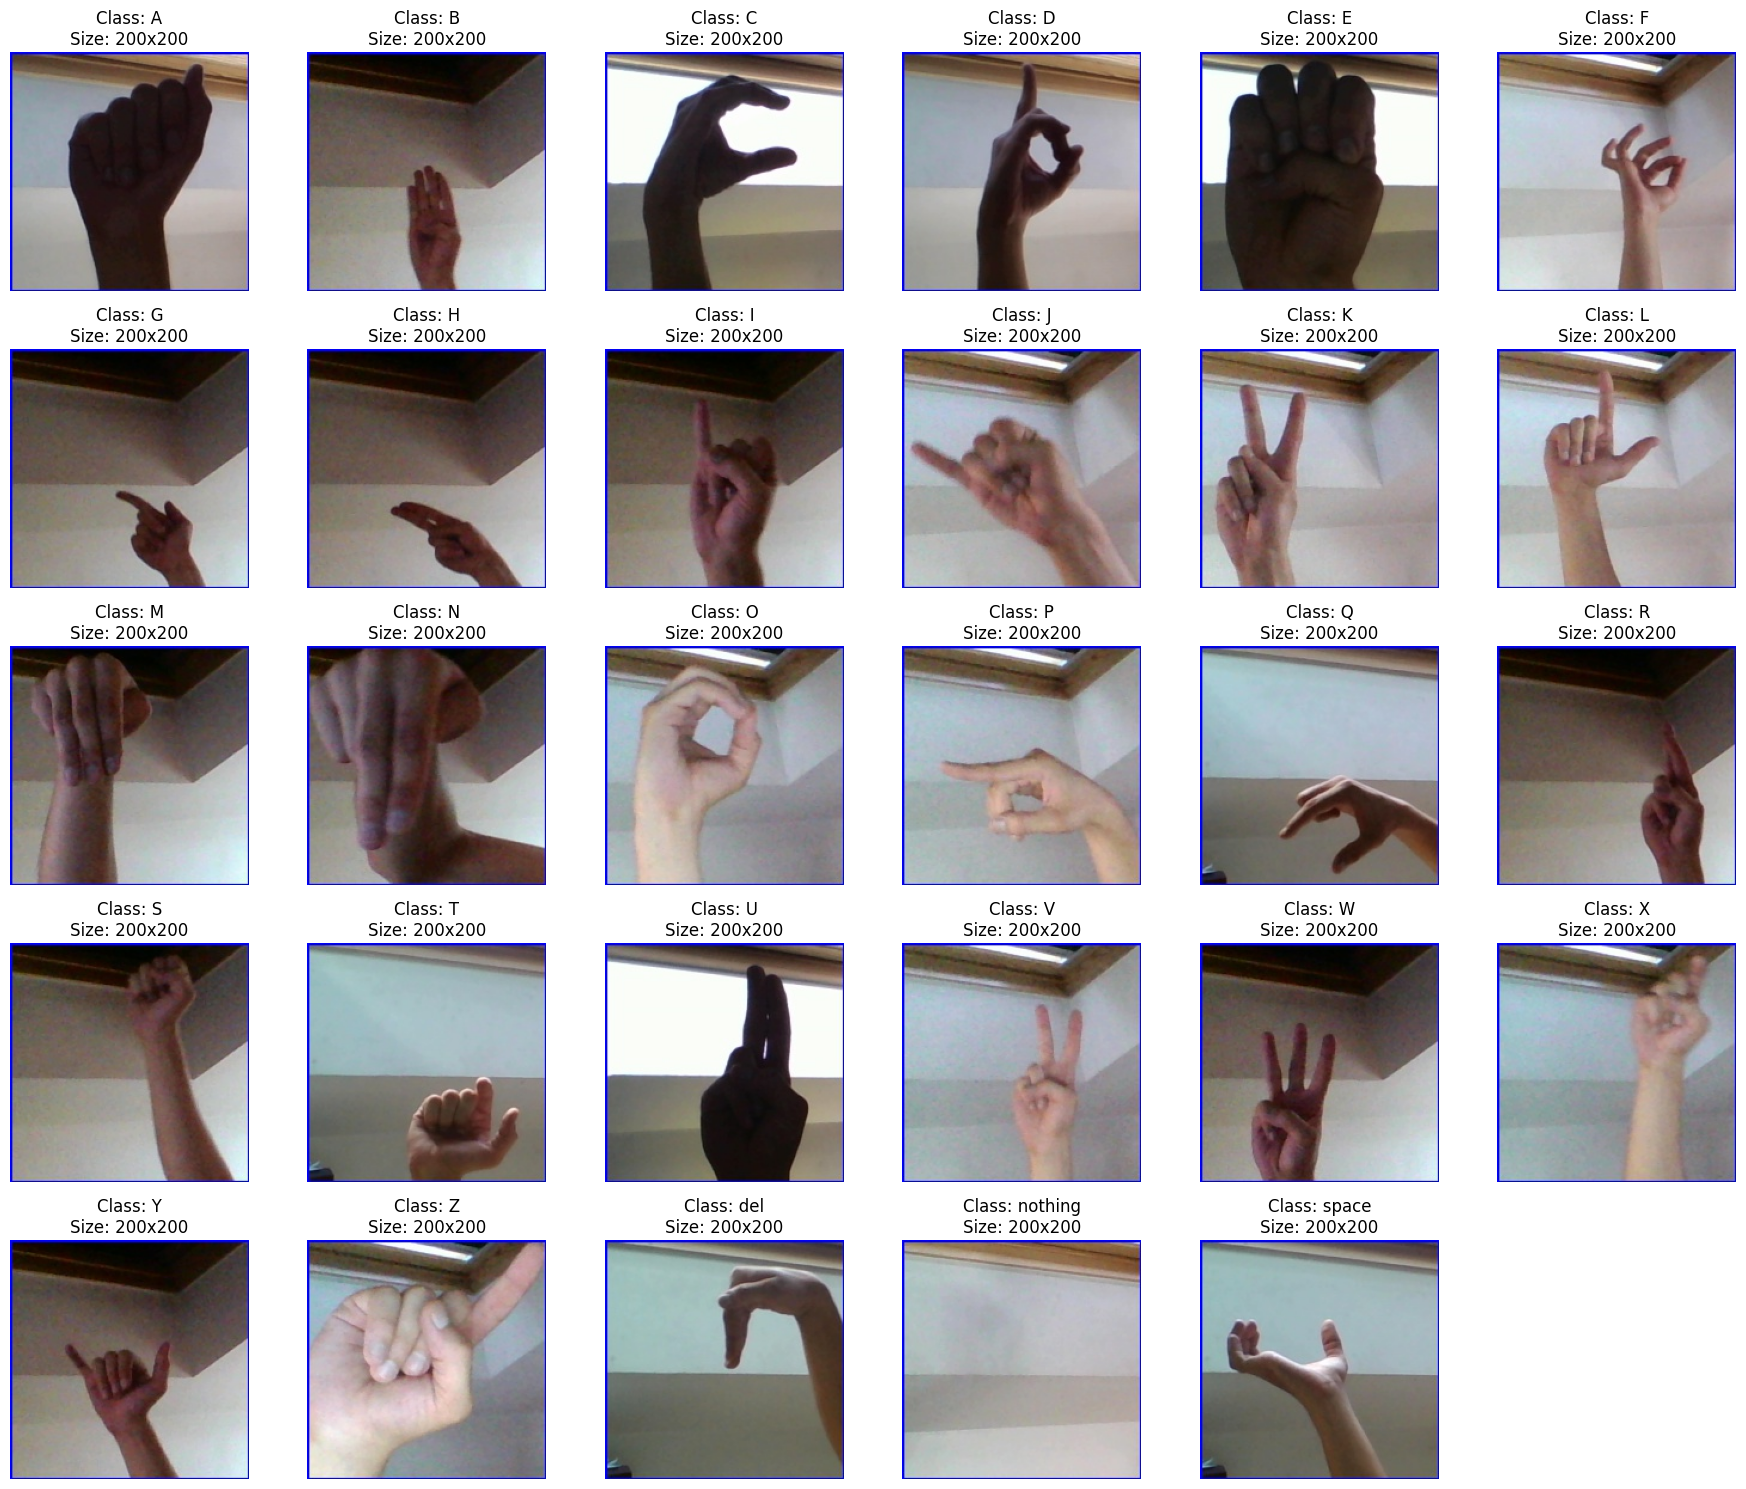

In [ ]:
# 5. Visualizing Sample Images
classes = sorted(df['class_name'].unique())
num_classes = len(classes)

cols = 6
rows = int(np.ceil(num_classes / cols))

plt.figure(figsize=(18, 3 * rows))
for i, cls in enumerate(classes):
    # Select a random image from this class
    sample_img_path = df[df['class_name'] == cls].sample(1).iloc[0]['image_path']
    img = cv2.imread(sample_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.title(f"Class: {cls}\nSize: {img.shape[1]}x{img.shape[0]}", fontsize=12)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# 6. Final Report Generation
print("="*60)
print(" Data Understanding & EDA Report (Person 1) ")
print("="*60)
print(f"1. Total number of images: {len(df)}")
print(f"2. Number of Classes: {df['class_name'].nunique()}")
print(f"   Classes: {sorted(df['class_name'].unique())}")
print(f"3. Imbalance Status: Data is completely balanced. Every class has exactly {class_counts.iloc[0]} images.")
print(f"4. Image Dimensions: All images are uniform. Size is {int(sample_df['width'].mean())}x{int(sample_df['height'].mean())} pixels.")
print(f"5. Image Mode: RGB (Color images).")


 Data Understanding & EDA Report (Person 1) 
1. Total number of images: 87000
2. Number of Classes: 29
   Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']
3. Imbalance Status: Data is completely balanced. Every class has exactly 3000 images.
4. Image Dimensions: All images are uniform. Size is 200x200 pixels.
5. Image Mode: RGB (Color images).


## **Data Preprocessing & Augmentation**

In [ ]:
# Check for corrupted or unreadable images in the dataset
print("Scanning for corrupted images...")

corrupted_files = []
for img_path in df['image_path']:
    try:
        img = cv2.imread(img_path)
        if img is None:
            corrupted_files.append(img_path)
    except Exception as e:
        corrupted_files.append(img_path)

if len(corrupted_files) == 0:
    print("Check passed: All images are valid and readable.")
else:
    print(f"Found {len(corrupted_files)} corrupted images.")
    df = df[~df['image_path'].isin(corrupted_files)].reset_index(drop=True)
    print("Corrupted images successfully removed.")

Scanning for corrupted images...
Check passed: All images are valid and readable.


In [ ]:
# Check for corrupted or unreadable images in the dataset
print("Scanning for corrupted images...")

corrupted_files = []
for img_path in df['image_path']:
    try:
        img = cv2.imread(img_path)
        if img is None:
            corrupted_files.append(img_path)
    except Exception as e:
        corrupted_files.append(img_path)

if len(corrupted_files) == 0:
    print("Check passed: All images are valid and readable.")
else:
    print(f"Found {len(corrupted_files)} corrupted images.")
    df = df[~df['image_path'].isin(corrupted_files)].reset_index(drop=True)
    print("Corrupted images successfully removed.")

Scanning for corrupted images...
Check passed: All images are valid and readable.


In [ ]:
# Split dataset into Training (80%) and Temporary (20%) sets
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df['class_name']
)

print(f"Training set: {len(train_df)} images")
print(f"Temporary set: {len(temp_df)} images")

Training set: 69600 images
Temporary set: 17400 images


In [ ]:
# Split Temporary set into Validation (10%) and Test (10%) sets
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df['class_name']
)

# Reset index for clean DataFrames
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Validation set: {len(val_df)} images")
print(f"Test set: {len(test_df)} images")

Validation set: 8700 images
Test set: 8700 images


In [ ]:
# Define target image size and batch size
IMG_WIDTH = 128
IMG_HEIGHT = 128
BATCH_SIZE = 32

print(f"Target Image Size: {IMG_WIDTH}x{IMG_HEIGHT}")
print(f"Batch Size: {BATCH_SIZE}")

Target Image Size: 128x128
Batch Size: 32


In [ ]:
# Define ImageDataGenerator with Data Augmentation for Training
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

print("Training generator setup complete with Data Augmentation.")

Training generator setup complete with Data Augmentation.


In [ ]:
# Define ImageDataGenerator for Validation and Test sets (Rescaling only)
valid_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Validation and Test generator setup complete with Rescaling.")

Validation and Test generator setup complete with Rescaling.


In [ ]:
# Create generator for Training set
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

Found 69600 validated image filenames belonging to 29 classes.


In [ ]:
# Create generator for Validation set
val_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8700 validated image filenames belonging to 29 classes.


In [ ]:
# Create generator for Test set
test_generator = valid_test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 8700 validated image filenames belonging to 29 classes.


In [ ]:
# Verify preprocessed output batch shape and values
sample_images, sample_labels = next(train_generator)

print("--- Preprocessing Verification ---")
print(f"Batch Image Shape: {sample_images.shape}")
print(f"Batch Label Shape: {sample_labels.shape}")
print(f"Min Pixel Value:   {sample_images.min():.2f}")
print(f"Max Pixel Value:   {sample_images.max():.2f}")

--- Preprocessing Verification ---
Batch Image Shape: (32, 128, 128, 3)
Batch Label Shape: (32, 29)
Min Pixel Value:   0.00
Max Pixel Value:   1.00


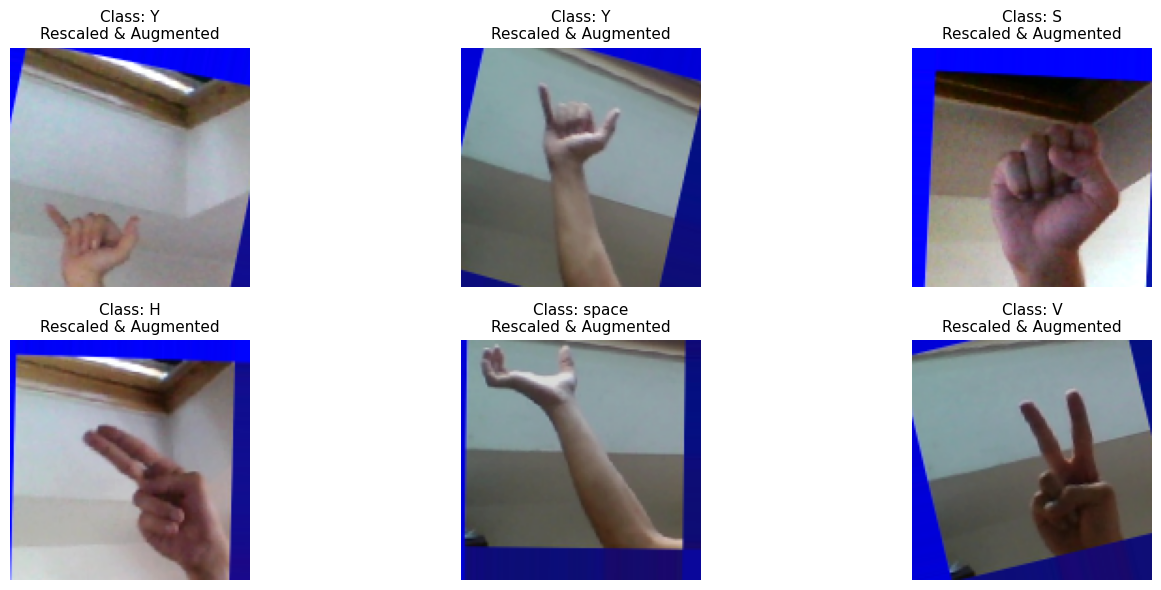

In [ ]:
# Visualize a sample batch of augmented and preprocessed images
plt.figure(figsize=(15, 6))
sample_images, sample_labels = next(train_generator)
class_labels = sorted(train_df['class_name'].unique())

for i in range(6):
    plt.subplot(2, 3, i + 1)
    # Convert one-hot encoded label back to class name
    label_idx = np.argmax(sample_labels[i])
    class_name = class_labels[label_idx]

    plt.imshow(sample_images[i])
    plt.title(f"Class: {class_name}\nRescaled & Augmented", fontsize=11)
    plt.axis('off')

plt.tight_layout()
plt.show()

#**modeling**




In [ ]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3), include_top=False, weights="imagenet"
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
base_model.trainable = False
num_classes = 29
inputs = tf.keras.Input(shape=(128, 128, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = models.Model(inputs, outputs, name="ASL_MobileNetV2")

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "ASL_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,598,493 (9.91 MB)

 Trainable params: 337,949 (1.29 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.2, patience=2, min_lr=1e-6
    ),
]

In [ ]:
# Create generator for Training set
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='class_name',
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

Found 69600 validated image filenames belonging to 29 classes.


In [ ]:
if "train_generator" not in globals() or "val_generator" not in globals():
    raise RuntimeError(
        "train_generator or val_generator is not defined. Please run the data preprocessing cells first!"
    )

EPOCHS = 15
print("Starting Model Training...")

history = model.fit(
    train_generator, validation_data=val_generator, epochs=EPOCHS, callbacks=callbacks
)

Starting Model Training...
Epoch 1/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 441s 194ms/step - accuracy: 0.7890 - loss: 0.6820 - val_accuracy: 0.9461 - val_loss: 0.1551 - learning_rate: 0.0010
Epoch 2/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 478s 220ms/step - accuracy: 0.8652 - loss: 0.4145 - val_accuracy: 0.9566 - val_loss: 0.1267 - learning_rate: 0.0010
Epoch 3/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 413s 190ms/step - accuracy: 0.8819 - loss: 0.3647 - val_accuracy: 0.9594 - val_loss: 0.1199 - learning_rate: 0.0010
Epoch 4/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 410s 189ms/step - accuracy: 0.8890 - loss: 0.3439 - val_accuracy: 0.9628 - val_loss: 0.1071 - learning_rate: 0.0010
Epoch 5/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 424s 195ms/step - accuracy: 0.8965 - loss: 0.3206 - val_accuracy: 0.9731 - val_loss: 0.0808 - learning_rate: 0.0010
Epoch 6/15
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 413s 190ms/step - accuracy: 0.9012 - loss: 0.3076 - val_accuracy: 0.9740 - val_loss: 0.0890 - learning_rate: 0.0010
Epoch 7/15
2175/2175 ━━━━

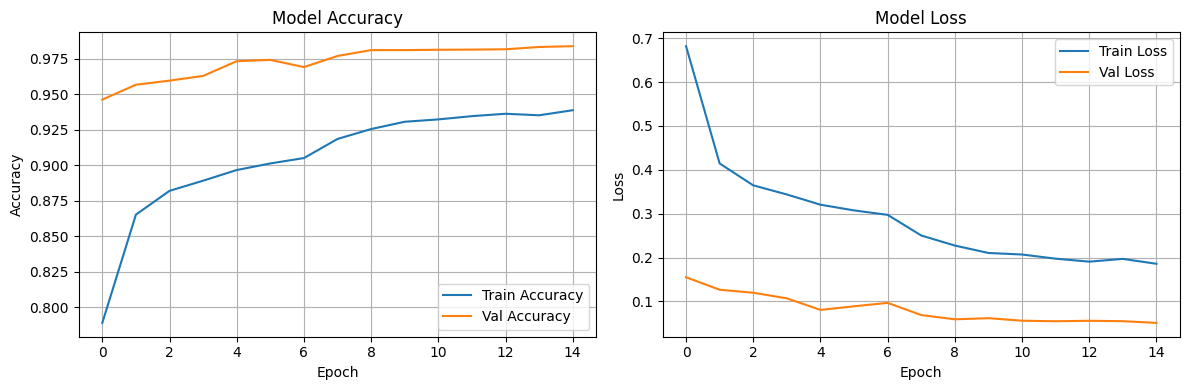

In [ ]:

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Evaluating model on Test Set...
272/272 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9821 - loss: 0.0536

--- Final Test Results ---
Test Loss: 0.0536
Test Accuracy: 98.21%

--- Classification Report ---
              precision    recall  f1-score   support

           A     1.0000    0.9833    0.9916       300
           B     0.9901    1.0000    0.9950       300
           C     1.0000    0.9867    0.9933       300
           D     1.0000    0.9933    0.9967       300
           E     0.9895    0.9467    0.9676       300
           F     1.0000    0.9967    0.9983       300
           G     1.0000    0.9700    0.9848       300
           H     1.0000    1.0000    1.0000       300
           I     0.9313    0.9933    0.9613       300
           J     0.9804    1.0000    0.9901       300
           K     0.9898    0.9733    0.9815       300
           L     1.0000    1.0000    1.0000       300
           M     0.9932    0.9800    0.9866       300
           N     0.9966    0.9867  

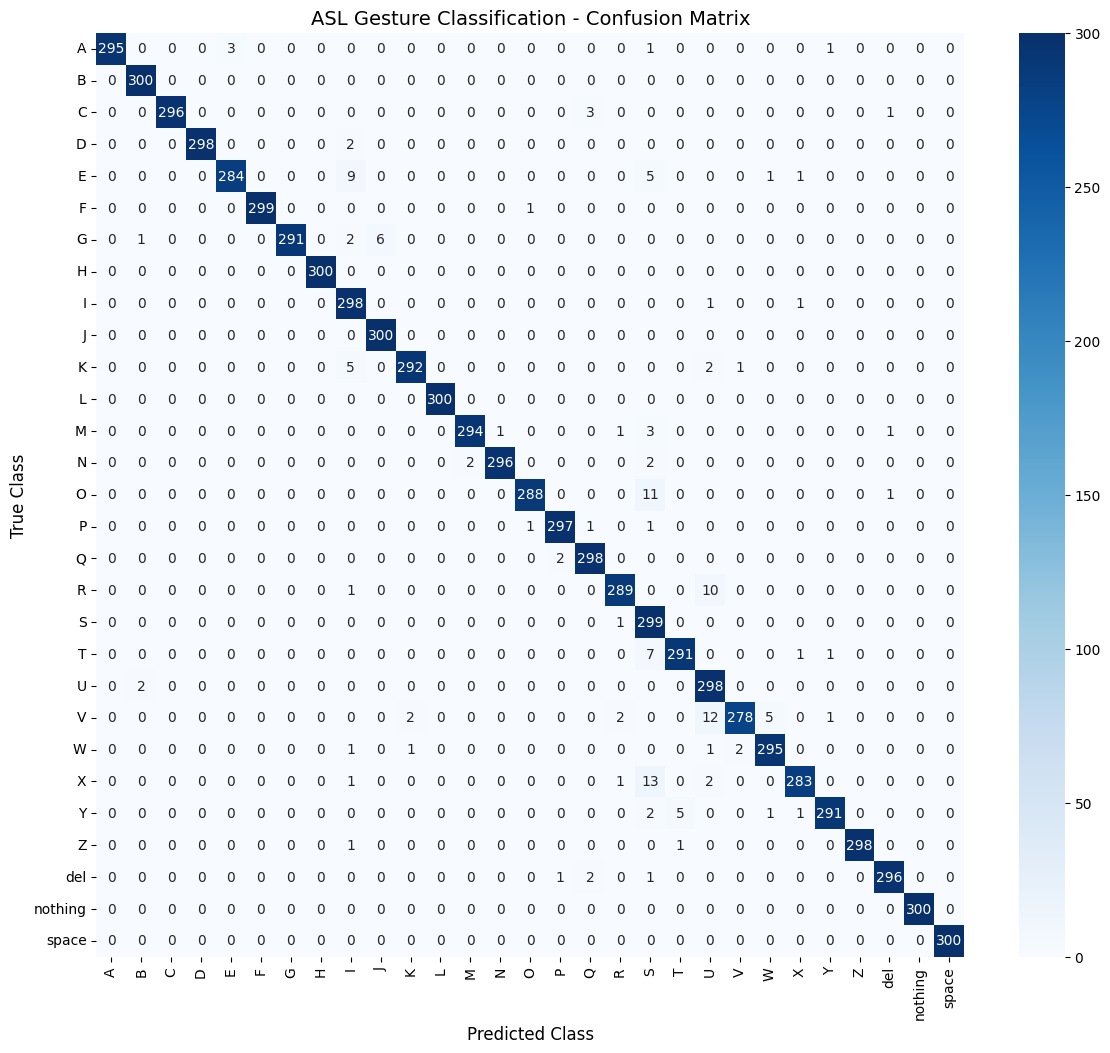

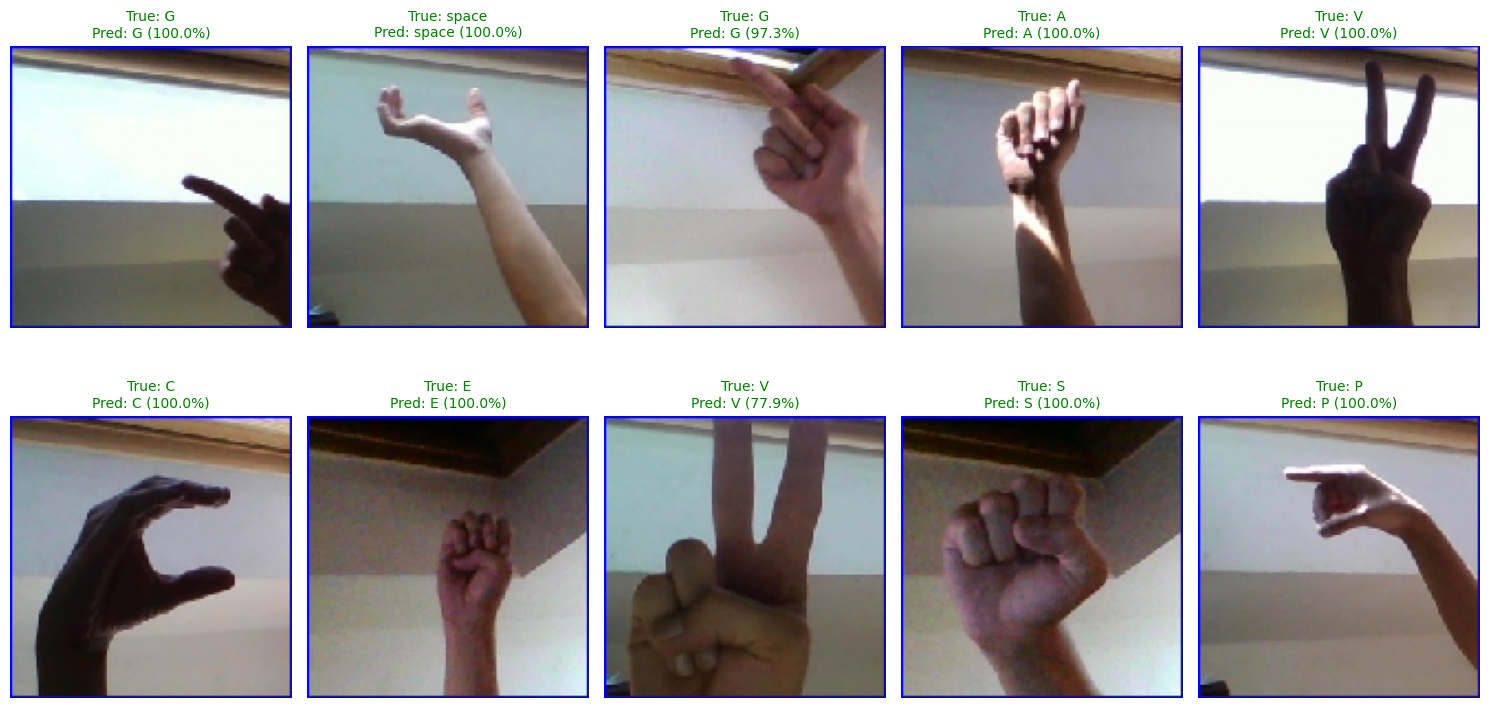

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Create label_to_index from train_generator.class_indices
label_to_index = train_generator.class_indices
# Reverse index dictionary to map prediction integers back to class letters
index_to_label = {idx: name for name, idx in label_to_index.items()}
class_names = [index_to_label[i] for i in range(num_classes)]

# 1. Evaluate on Unseen Test Dataset
print("Evaluating model on Test Set...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n--- Final Test Results ---")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

# 2. Generate True Labels and Model Predictions
y_true = []
y_pred_probs = []

# Reset test_generator to ensure predictions start from the beginning
test_generator.reset()

batch_count = 0
total_batches = len(test_generator)

for images, labels in test_generator:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels, axis=1)) # labels from generator are already one-hot encoded
    y_pred_probs.extend(preds)

    batch_count += 1
    if batch_count >= total_batches:
        break


y_true = np.array(y_true)
y_pred = np.argmax(np.array(y_pred_probs), axis=1)

# 3. Print Comprehensive Classification Report
print("\n--- Classification Report ---")
print(
    classification_report(y_true, y_pred, target_names=class_names, digits=4)
)

# 4. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("ASL Gesture Classification - Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.show()

# 5. Visualize Sample Test Predictions
plt.figure(figsize=(15, 8))

# Get a batch from the test generator for visualization
# Resetting again to get fresh batch for visualization
test_generator.reset()
sample_images, sample_labels = next(test_generator)

preds = model.predict(sample_images, verbose=0)
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(sample_images[i])

    actual_cls = index_to_label[np.argmax(sample_labels[i])]
    pred_cls = index_to_label[np.argmax(preds[i])]
    confidence = np.max(preds[i]) * 100

    color = "green" if actual_cls == pred_cls else "red"
    plt.title(
        f"True: {actual_cls}\nPred: {pred_cls} ({confidence:.1f}%)",
        color=color,
        fontsize=10,
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

base_model = Sequential([

    # Convolution Layer 1
    Conv2D(
        32,
        (3, 3),
        activation="relu",
        input_shape=(128, 128, 3)
    ),

    MaxPooling2D((2, 2)),

    # Convolution Layer 2
    Conv2D(
        64,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    # Convolution Layer 3
    Conv2D(
        128,
        (3, 3),
        activation="relu"
    ),

    MaxPooling2D((2, 2)),

    # Convert Feature Maps to Vector
    Flatten(),

    # Fully Connected Layer
    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    # Output Layer
    Dense(
        num_classes,
        activation="softmax"
    )
])

base_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 29)             │         3,741 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,308,381 (12.62 MB)

 Trainable params: 3,308,381 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
base_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history_base = base_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 407s 185ms/step - accuracy: 0.3770 - loss: 1.9870 - val_accuracy: 0.7743 - val_loss: 0.6771
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 406s 186ms/step - accuracy: 0.6454 - loss: 1.0034 - val_accuracy: 0.8949 - val_loss: 0.2997
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 405s 186ms/step - accuracy: 0.7457 - loss: 0.7034 - val_accuracy: 0.9441 - val_loss: 0.1756
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 409s 188ms/step - accuracy: 0.8000 - loss: 0.5553 - val_accuracy: 0.9549 - val_loss: 0.1315
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 407s 187ms/step - accuracy: 0.8348 - loss: 0.4588 - val_accuracy: 0.9776 - val_loss: 0.0742
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 410s 188ms/step - accuracy: 0.8594 - loss: 0.3958 - val_accuracy: 0.9808 - val_loss: 0.0603
Epoch 7/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 416s 191ms/step - accuracy: 0.8776 - loss: 0.3440 - val_accuracy: 0.9729 - val_loss: 0.0759
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 415s 191ms/step - ac

In [ ]:
test_generator.reset()

loss, acc = base_model.evaluate(
    test_generator,
    verbose=1
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {acc * 100:.2f}%")

272/272 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.9922 - loss: 0.0264
Test Loss: 0.0264
Test Accuracy: 99.22%


In [ ]:
test_generator.reset()

y_true_evolution = []
y_pred_evolution = []

for _ in range(len(test_generator)):

    images, labels = next(test_generator)

    predictions = base_model.predict(
        images,
        verbose=0
    )

    y_true_evolution.extend(
        np.argmax(labels, axis=1)
    )

    y_pred_evolution.extend(
        np.argmax(predictions, axis=1)
    )

y_true_evolution = np.array(y_true_evolution)
y_pred_evolution = np.array(y_pred_evolution)

print("✅ Predictions completed")

✅ Predictions completed


In [ ]:
print(
    classification_report(
        y_true_evolution,
        y_pred_evolution,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

           A     0.9933    0.9900    0.9917       300
           B     0.9868    0.9967    0.9917       300
           C     1.0000    1.0000    1.0000       300
           D     1.0000    1.0000    1.0000       300
           E     0.9803    0.9967    0.9884       300
           F     1.0000    1.0000    1.0000       300
           G     1.0000    0.9967    0.9983       300
           H     0.9967    1.0000    0.9983       300
           I     0.9901    0.9967    0.9934       300
           J     0.9967    0.9933    0.9950       300
           K     0.9934    1.0000    0.9967       300
           L     1.0000    1.0000    1.0000       300
           M     0.9834    0.9867    0.9850       300
           N     0.9933    0.9867    0.9900       300
           O     1.0000    1.0000    1.0000       300
           P     1.0000    0.9933    0.9967       300
           Q     1.0000    1.0000    1.0000       300
           R     0.9965    

In [ ]:
test_generator.reset()

test_loss, test_acc = base_model.evaluate(
    test_generator,
    verbose=1
)

print(f"Base Model Loss: {test_loss:.4f}")
print(f"Base Model Accuracy: {test_acc * 100:.2f}%")

272/272 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.9922 - loss: 0.0264
Base Model Loss: 0.0264
Base Model Accuracy: 99.22%


In [ ]:
test_generator.reset()


evolution_loss, evolution_acc = model.evaluate(
    test_generator,
    verbose=1
)

print(f"Evolution Model Loss: {evolution_loss:.4f}")
print(f"Evolution Model Accuracy: {evolution_acc * 100:.2f}%")

272/272 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9821 - loss: 0.0536
Evolution Model Loss: 0.0536
Evolution Model Accuracy: 98.21%


In [ ]:
print("===================================")
print("       MODEL COMPARISON")
print("===================================")

print(f"Base Model Accuracy      : {test_acc * 100:.2f}%")
print(f"Evolution Model Accuracy : {evolution_acc * 100:.2f}%")

difference = (evolution_acc - test_acc) * 100

print(f"Difference               : {difference:+.2f}%")

       MODEL COMPARISON
Base Model Accuracy      : 99.22%
Evolution Model Accuracy : 98.21%
Difference               : -1.01%


In [ ]:
base_model.save("asl_model.keras")

print("✅ base Model saved successfully")

✅ base Model saved successfully
